### 1. Fundamental Parameters

In [1]:
from model import alpha, self_energy
from smatrix import create_self_energy_interpolator_numba
import numpy as np
from eigenstate_solving import BZ_proj
from model import square_lattice
from W_state import q_bounds, peak_width_estimator


sigma_data = np.load("../../data/sigma_grid0f1a.npz")
kx = sigma_data["kx"]
ky = sigma_data["ky"]
sigma_grid = sigma_data["sigma_grid"]
sigma_func_period_numba = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)
collective_lamb_shift = self_energy(
    0, 0, square_lattice.a, square_lattice.d, square_lattice.omega_e, alpha
).real
sigma_func_period_numba = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)
# r_para = np.array([-74, 30])
# p_para = np.array([60, 50])
p_para = np.array([0.0, 0.0])
r_para = np.array([0.0,0.0])
#p_para = np.array([86.0,0.0])

E = 2 * (square_lattice.omega_e + collective_lamb_shift) + 0.25
E1 = E/2 + 1
Zc = 0

# for FFT
eta = 1e-5 # singularity broadening
n_Rs= 10 # number of points to resolve the singularity in the numerical grid
n_points = int(2e6) # number of grid for FFT

Q_para = np.array([0, 0])


if np.linalg.norm(r_para) + np.linalg.norm(BZ_proj(Q_para-r_para,square_lattice)) > E:
    raise ValueError("In plane-wave basis, the total in-plane photon momenta exceeds the total energy.")

if np.linalg.norm(p_para) + np.linalg.norm(BZ_proj(Q_para-p_para,square_lattice)) > E:
    raise ValueError("In W-state label, the total in-plane photon momenta exceeds the total energy.")



q_min, q_max = q_bounds(E, r_para, Q_para, square_lattice)
q_grid = np.linspace(q_min + 1e-10, q_max - 1e-10, n_points, endpoint=False)
dq = q_grid[1] - q_grid[0]



In [2]:
from smatrix import tau_matrix_element
from I_term import C_term


MEQ =  tau_matrix_element(E, Q_para, square_lattice, sigma_func_period_numba)
# vegas integral is used in computing C_term
C_term = C_term(E,Q_para,p_para,E1,square_lattice,sigma_func_period_numba,eta,MEQ,True,nitn=10,neval=int(5e6))

#MEQ = 0.00163882765903532-3.921228271722614e-05j
#C_term = 1.7130517367773706e-08+4.188314901662984e-08j

/Users/ywan8652/research_project/2D_array/.venv/lib/python3.14/site-packages/scipy/integrate/_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
/Users/ywan8652/research_project/2D_array/.venv/lib/python3.14/site-packages/scipy/integrate/_quadpack_py.py:1286: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
/Users/ywan8652/research_project/2D_array/.venv/lib/python3.14/site-packages/scipy/integrate/_quadpack_py.py:1286: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
/Users/ywan8652/research_project/2D_array/.venv/lib/python3.14/site-packages/scipy/integrate

In [3]:
peak_width = peak_width_estimator(r_para, p_para, E1, E, Q_para,eta,int(n_points),square_lattice, sigma_func_period_numba)


if peak_width is not None:
    if not np.isfinite(peak_width):
        raise ValueError("peak_width_estimator returned non-finite width.")
    elif peak_width < n_Rs*dq:
        raise ValueError(f"eta is not big enough to broaden the peak to be {n_Rs} grid points.")


### 2. Discrete FFT Part

For the discrete FFT grid used below, $q_j=q_{\min}+j\Delta q$ with `endpoint=False`, so $\Delta q\simeq(q_{\max}-q_{\min})/n$ (up to the small endpoint offset). The conjugate coordinate grid is $z_k=2\pi\,\mathrm{fftfreq}(n,d=\Delta q)$, so the non-aliased range is $|z|\le L$ with $L=\pi/\Delta q$, and the spacing is $\Delta z=2L/n=2\pi/(n\Delta q)$.

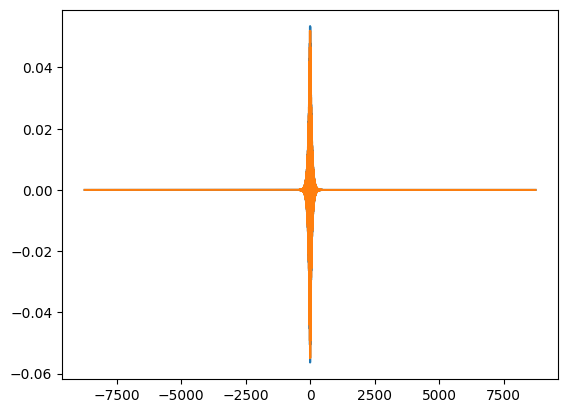

In [4]:
from scipy.fft import ifft
from W_state import W_k_sp_grid
import matplotlib.pyplot as plt

def FFT(value_grid, q_grid):
    local_dq = q_grid[1] - q_grid[0]
    local_n_points = len(q_grid)
    z_grid = 2 * np.pi * np.fft.fftfreq(local_n_points, d=local_dq)

    # value_grid_ifft = (q_max-q_min)*ifft(value_grid)
    value_grid_ifft = 1/(2*np.pi)*local_n_points * local_dq * ifft(value_grid)
    value_grid_ifft *= np.exp(1j * q_grid[0] * z_grid)

    # Only compare where the q grid resolves exp(i q z) with several samples per period.
    min_samples_per_period = 8
    resolved_z = 2 * np.pi / (min_samples_per_period * local_dq)
    keep = np.abs(z_grid) <= resolved_z

    z_grid = z_grid[keep] # Keep only the resolved z values
    value_grid_ifft = value_grid_ifft[keep]
    
    return z_grid, value_grid_ifft


value_grid = W_k_sp_grid(
    r_para,
    p_para,
    E1,
    E,
    Q_para,
    Zc,
    square_lattice,
    sigma_func_period_numba,
    n_points,
    q_grid,
    eta,
    MEQ,
    C_term)



z_grid, value_grid_ifft = FFT(value_grid, q_grid)

"""
plot_idx = np.argsort(z_grid[keep])
plt.plot(z_grid[keep][plot_idx], np.real(value_grid_ifft[keep][plot_idx]))
plt.plot(z_grid[keep][plot_idx], np.imag(value_grid_ifft[keep][plot_idx]))
"""


plot_idx = np.argsort(z_grid)
plt.plot(z_grid[plot_idx], np.real(value_grid_ifft[plot_idx]))
plt.plot(z_grid[plot_idx], np.imag(value_grid_ifft[plot_idx]))

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   4 out of  11 | elapsed:    9.9s remaining:   17.4s
[Parallel(n_jobs=6)]: Done   8 out of  11 | elapsed:   11.6s remaining:    4.4s
[Parallel(n_jobs=6)]: Done  11 out of  11 | elapsed:   12.8s finished


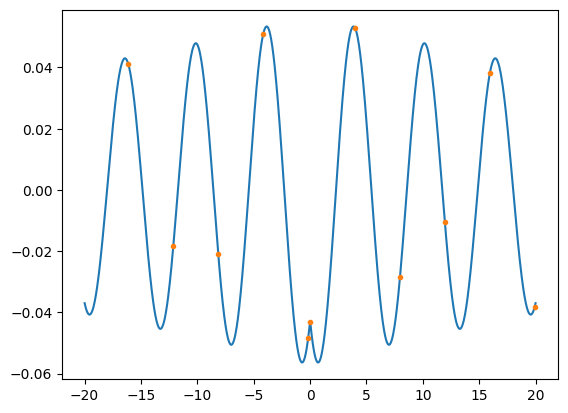

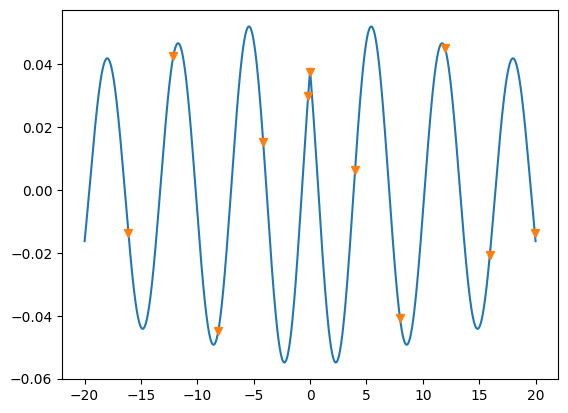

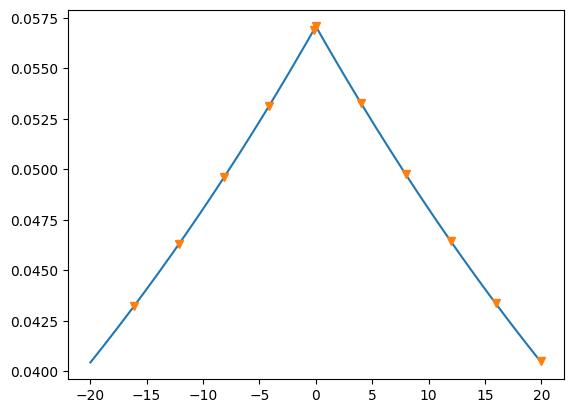

In [5]:
from joblib import Parallel, delayed
from W_state import quad_FT

plot_mask = np.abs(z_grid) <= 20
plot_z_grid = z_grid[plot_mask]
plot_value_grid_ifft = value_grid_ifft[plot_mask]

n_intg_sample_point = 10
sample_step = max(1, len(plot_z_grid) // n_intg_sample_point)
z_sample = plot_z_grid[::sample_step]

n_quad_jobs = 6


def _compute_quad_ft(z_val):
    return quad_FT(
        r_para,
        p_para,
        Zc,
        z_val,
        E1,
        E,
        Q_para,
        square_lattice,
        sigma_func_period_numba,
        eta,
        MEQ,
        C_term
    )


quad_pairs = Parallel(n_jobs=n_quad_jobs, verbose=3)(
    delayed(_compute_quad_ft)(z_val) for z_val in z_sample
)
quad_result, quad_err = map(np.asarray, zip(*quad_pairs))


sorted_idx = np.argsort(plot_z_grid)
plt.plot(plot_z_grid[sorted_idx], np.real(plot_value_grid_ifft[sorted_idx]))
plt.plot(z_sample, np.real(quad_result), ".")
plt.show()

plt.plot(plot_z_grid[sorted_idx], np.imag(plot_value_grid_ifft[sorted_idx]))
plt.plot(z_sample, np.imag(quad_result), "v")
plt.show()


plt.plot(plot_z_grid[sorted_idx], np.abs(plot_value_grid_ifft[sorted_idx]))
plt.plot(z_sample, np.abs(quad_result), "v")
plt.show()

In [ ]:
from W_state import W_disconnect

disc_part = W_disconnect(z_grid,Zc,r_para,p_para,E1,E,Q_para,square_lattice)

plt.plot(q_grid[mask_tmp], np.real(value_grid)[mask_tmp])


array([78.95683521+0.00000000e+00j, 78.90863637+0.00000000e+00j,
       78.76409868+5.47873103e-16j, ..., 78.52339863+0.00000000e+00j,
       78.76409868-5.47873103e-16j, 78.90863637+0.00000000e+00j],
      shape=(500001,))

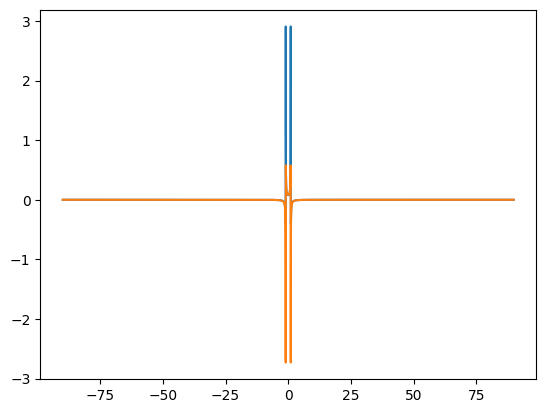

In [6]:
mask_tmp = (q_grid <= 200) & (q_grid >= -200)
plt.plot(q_grid[mask_tmp], np.real(value_grid)[mask_tmp])
plt.plot(q_grid[mask_tmp], np.imag(value_grid)[mask_tmp])


In [7]:
from joblib import Parallel, delayed


n_r_grid_points = 30 # number of grid points along each direction in the r_para path inside the light cone
r_path = []

vertical_r_grid_points =  np.linspace(0,E/2,n_r_grid_points,endpoint=False)
diagonal_r_grid_points =  np.linspace(0,E/2/np.sqrt(2),n_r_grid_points,endpoint=False)

# go through the grid in reverse order but skip the first point (0,0) to avoid duplication
for x in vertical_r_grid_points[:1:-1]:
    r_path.append(np.array([x, 0.0]))

r_path.append(np.array([0.01, 0.01]))

for x in diagonal_r_grid_points[1:]:
    r_path.append(np.array([x, x]))


n_jobs = 6  # use all available CPU cores; set to a positive integer to limit workers
eta = 1e-5

def _compute_q_distribution(r_para,eta):
    q_min, q_max = q_bounds(E, r_para, Q_para, square_lattice)
    local_dq = (q_max - q_min) / n_points
    q_grid = q_min + (np.arange(n_points) + 0.5) * local_dq

    peak_width = peak_width_estimator(r_para, p_para, E1, E, Q_para,eta,int(n_points),square_lattice, sigma_func_period_numba)
    if peak_width is not None:
        if not np.isfinite(peak_width):
            raise ValueError("peak_width_estimator returned non-finite width.")
        elif peak_width < n_Rs*local_dq:
            raise ValueError(f"eta is not big enough to broaden the peak to be {n_Rs} grid points.")

    q_distribution =  W_k_sp_grid(
        r_para,
        p_para,
        E1,
        E,
        Q_para,
        Zc,
        square_lattice,
        sigma_func_period_numba,
        n_points,
        q_grid,
        eta,
        MEQ,
        C_term
    )

    z_grid,value_grid_ifft = FFT(q_distribution, q_grid)

    return q_grid, q_distribution, z_grid, value_grid_ifft

q_distribution_results = Parallel(n_jobs=n_jobs, verbose=3)(
    delayed(_compute_q_distribution)(r_para,eta) for r_para in r_path
)
q_grid_list, q_distribution_list, z_grid_list, value_grid_ifft_list = map(list, zip(*q_distribution_results))





[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


No pole on the real axis, no eta is needed.
No pole on the real axis, no eta is needed.
No pole on the real axis, no eta is needed.
No pole on the real axis, no eta is needed.
No pole on the real axis, no eta is needed.
No pole on the real axis, no eta is needed.


/Users/ywan8652/research_project/2D_array/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=6)]: Done  20 tasks      | elapsed:  2.3min


No pole on the real axis, no eta is needed.
No pole on the real axis, no eta is needed.
No pole on the real axis, no eta is needed.
No pole on the real axis, no eta is needed.
No pole on the real axis, no eta is needed.
No pole on the real axis, no eta is needed.


[Parallel(n_jobs=6)]: Done  58 out of  58 | elapsed:  5.5min finished


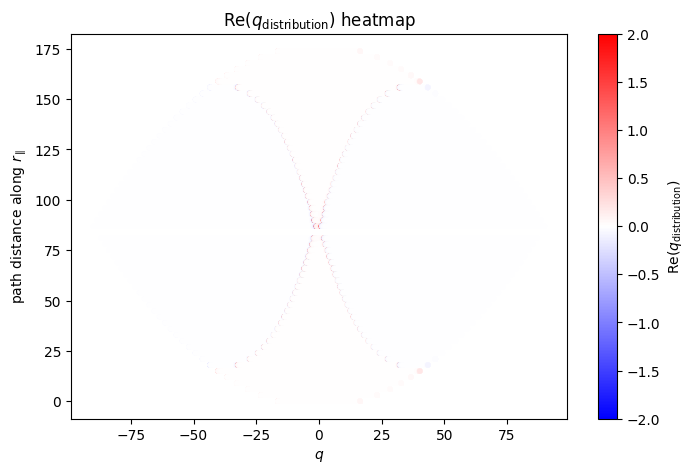

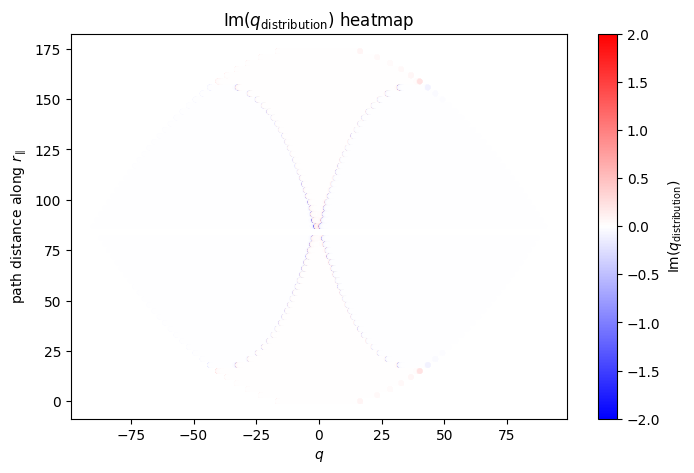

In [ ]:
r_path_arr = np.asarray(r_path)
r_path_steps = np.linalg.norm(np.diff(r_path_arr, axis=0), axis=1)
r_heatmap_points = np.concatenate(([0.0], np.cumsum(r_path_steps)))
q_re = np.real(np.asarray(q_distribution_list))
q_im = np.imag(np.asarray(q_distribution_list))

if q_re.shape[0] != len(r_heatmap_points) or q_im.shape[0] != len(r_heatmap_points):
    raise ValueError("The number of q_distribution rows must match r_heatmap_points.")

# Keep the full-resolution arrays for computation, but decimate the q-axis for plotting.
# Plotting all n_points columns can be much slower than computing a small heatmap view.
max_q_plot_points = 10000
q_plot_stride = max(1, q_re.shape[1] // max_q_plot_points)
q_plot_idx = slice(None, None, q_plot_stride)

q_re_plot = q_re[:, q_plot_idx]
q_im_plot = q_im[:, q_plot_idx]

def _same_q_grid_after_decimation(q_grids):
    first = np.asarray(q_grids[0])[q_plot_idx]
    return all(
        np.asarray(q).shape == np.asarray(q_grids[0]).shape
        and np.allclose(first, np.asarray(q)[q_plot_idx])
        for q in q_grids[1:]
    )

def _plot_q_distribution_heatmap(values, colorbar_label, title,vmin,vmax):
    if "q_grid_list" in globals() and _same_q_grid_after_decimation(q_grid_list):
        fig, ax = plt.subplots(figsize=(8, 5))
        mesh = ax.pcolormesh(np.asarray(q_grid_list[0])[q_plot_idx], r_heatmap_points, values, shading="auto",vmin=vmin,vmax=vmax,cmap="bwr")
    elif "q_grid_list" in globals():
        q_heatmap_grid = np.asarray([np.asarray(q)[q_plot_idx] for q in q_grid_list])
        r_heatmap_grid = np.repeat(r_heatmap_points[:, None], q_heatmap_grid.shape[1], axis=1)
        fig, ax = plt.subplots(figsize=(8, 5))
        mesh = ax.scatter(q_heatmap_grid.ravel(), r_heatmap_grid.ravel(), c=values.ravel(), s=8,vmin=vmin,vmax=vmax,cmap="bwr")
    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        mesh = ax.pcolormesh(np.asarray(q_grid)[q_plot_idx], r_heatmap_points, values, shading="auto",vmin=vmin,vmax=vmax)

    fig.colorbar(mesh, ax=ax, label=colorbar_label)
    ax.set_xlabel(r"$q$")
    ax.set_ylabel(r"path distance along $r_\parallel$")
    ax.set_title(title)
    plt.show()

_plot_q_distribution_heatmap(
    q_re_plot,
    r"$\mathrm{Re}(q_{\mathrm{distribution}})$",
    r"$\mathrm{Re}(q_{\mathrm{distribution}})$ heatmap",-2,2
)
_plot_q_distribution_heatmap(
    q_im_plot,
    r"$\mathrm{Im}(q_{\mathrm{distribution}})$",
    r"$\mathrm{Im}(q_{\mathrm{distribution}})$ heatmap",-2,2
)


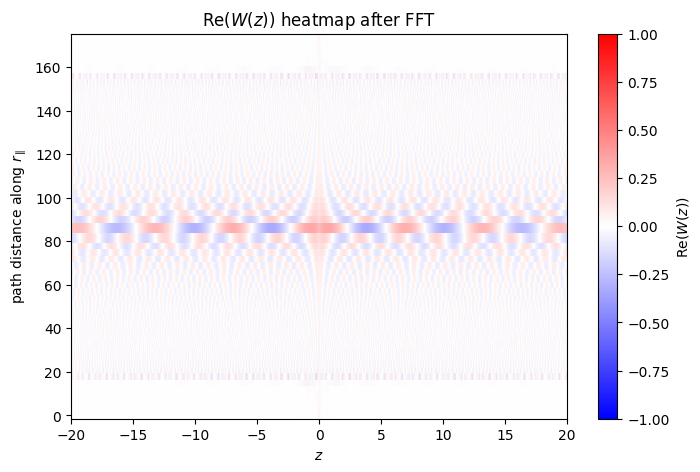

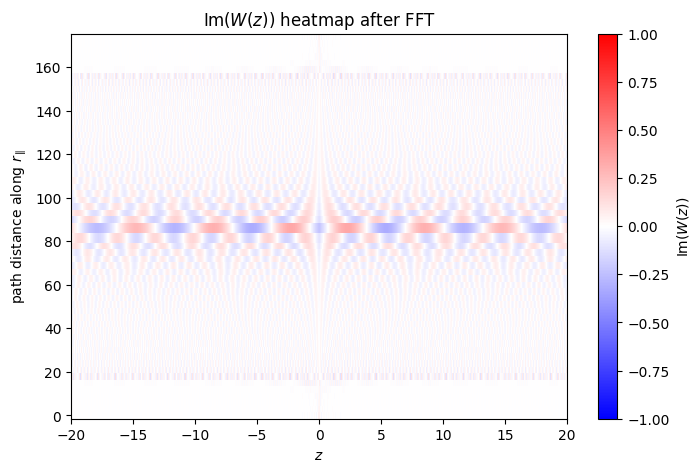

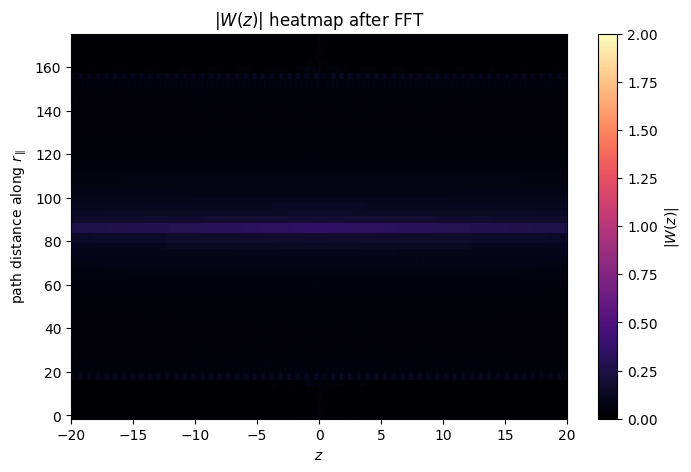

In [ ]:
z_plot_min = -20
z_plot_max = 20
max_z_plot_points = 10000
common_z_grid = np.linspace(z_plot_min, z_plot_max, max_z_plot_points)

def _interpolate_fft_row(z_grid, value_grid, common_z_grid):
    z_arr = np.asarray(z_grid)
    value_arr = np.asarray(value_grid)
    if z_arr.shape != value_arr.shape:
        raise ValueError("Each z_grid and FFT value row must have matching shapes.")

    sort_idx = np.argsort(z_arr)
    z_sorted = z_arr[sort_idx]
    value_sorted = value_arr[sort_idx]

    if common_z_grid[0] < z_sorted[0] or common_z_grid[-1] > z_sorted[-1]:
        raise ValueError("The requested z plotting window extends outside at least one FFT row's z range.")

    real_interp = np.interp(common_z_grid, z_sorted, np.real(value_sorted))
    imag_interp = np.interp(common_z_grid, z_sorted, np.imag(value_sorted))
    return real_interp + 1j * imag_interp

z_values = np.vstack([
    _interpolate_fft_row(z_grid, value_grid_ifft, common_z_grid)
    for z_grid, value_grid_ifft in zip(z_grid_list, value_grid_ifft_list)
])
z_re = np.real(z_values)
z_im = np.imag(z_values)
z_abs = np.abs(z_values)

if z_re.shape[0] != len(r_heatmap_points) or z_im.shape[0] != len(r_heatmap_points):
    raise ValueError("The number of z-space rows must match r_heatmap_points.")

z_re_window = z_re
z_im_window = z_im
z_abs_window = z_abs
z_grid_window_list = [common_z_grid for _ in z_grid_list]

# Keep the full-resolution arrays for computation, but decimate the selected z-axis window for plotting.
z_plot_stride = max(1, z_re_window.shape[1] // max_z_plot_points)
z_plot_idx = slice(None, None, z_plot_stride)

z_re_plot = z_re_window[:, z_plot_idx]
z_im_plot = z_im_window[:, z_plot_idx]
z_abs_plot = z_abs_window[:, z_plot_idx]
z_grid_plot_list = [np.asarray(z)[z_plot_idx] for z in z_grid_window_list]

if z_grid_plot_list:
    z_sort_idx = np.argsort(z_grid_plot_list[0])
    z_grid_plot_list = [z[z_sort_idx] for z in z_grid_plot_list]
    z_re_plot = z_re_plot[:, z_sort_idx]
    z_im_plot = z_im_plot[:, z_sort_idx]
    z_abs_plot = z_abs_plot[:, z_sort_idx]

def _same_z_grid_after_decimation(z_grids):
    first = np.asarray(z_grids[0])
    return all(
        np.asarray(z).shape == np.asarray(z_grids[0]).shape
        and np.allclose(first, np.asarray(z))
        for z in z_grids[1:]
    )

def _symmetric_color_limits(values, percentile=99):
    finite = np.asarray(values)[np.isfinite(values)]
    if finite.size == 0:
        return None, None
    limit = np.percentile(np.abs(finite), percentile)
    if limit == 0:
        return None, None
    return -limit, limit

def _positive_color_limits(values, percentile=99):
    finite = np.asarray(values)[np.isfinite(values)]
    if finite.size == 0:
        return None, None
    upper = np.percentile(finite, percentile)
    if upper == 0:
        return None, None
    return 0, upper

def _plot_z_distribution_heatmap(values, colorbar_label, title, cmap="bwr", vmin=None, vmax=None):
    if z_grid_plot_list and _same_z_grid_after_decimation(z_grid_plot_list):
        fig, ax = plt.subplots(figsize=(8, 5))
        mesh = ax.pcolormesh(
            z_grid_plot_list[0],
            r_heatmap_points,
            values,
            shading="auto",
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
        )
    elif z_grid_plot_list:
        z_heatmap_grid = np.asarray(z_grid_plot_list)
        r_heatmap_grid = np.repeat(r_heatmap_points[:, None], z_heatmap_grid.shape[1], axis=1)
        fig, ax = plt.subplots(figsize=(8, 5))
        mesh = ax.scatter(
            z_heatmap_grid.ravel(),
            r_heatmap_grid.ravel(),
            c=values.ravel(),
            s=8,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
        )
    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        mesh = ax.pcolormesh(
            np.asarray(z_grid)[z_plot_idx],
            r_heatmap_points,
            values,
            shading="auto",
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
        )

    fig.colorbar(mesh, ax=ax, label=colorbar_label)
    ax.set_xlabel(r"$z$")
    ax.set_ylabel(r"path distance along $r_\parallel$")
    ax.set_title(title)
    plt.show()

z_re_vmin, z_re_vmax = _symmetric_color_limits(z_re_plot)
z_im_vmin, z_im_vmax = _symmetric_color_limits(z_im_plot)
z_abs_vmin, z_abs_vmax = _positive_color_limits(z_abs_plot)

_plot_z_distribution_heatmap(
    z_re_plot,
    r"$\mathrm{Re}(W(z))$",
    r"$\mathrm{Re}(W(z))$ heatmap after FFT",
#    vmin=z_re_vmin,    vmax=z_re_vmax,
    vmin = -1,vmax = 1
)
_plot_z_distribution_heatmap(
    z_im_plot,
    r"$\mathrm{Im}(W(z))$",
    r"$\mathrm{Im}(W(z))$ heatmap after FFT",
#    vmin=z_im_vmin,#  vmax=z_im_vmax,
    vmin = -1,vmax = 1
)
_plot_z_distribution_heatmap(
    z_abs_plot,
    r"$|W(z)|$",
    r"$|W(z)|$ heatmap after FFT",
    cmap="magma",
#    vmin=z_abs_vmin, vmax=z_abs_vmax,
    vmin = 0,vmax = 2
)


In [ ]:



z_array = np.linspace(0,1.0,10)

W_disconnect(z_array,np.array([0.1,0.2]),p_para,E1,square_lattice)

array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j])